# 🤖 Machine-Learning Trading Signal with Alpaca (Paper Trading Only)

**Homework 3.** Build a simple ML trading signal on Alpaca market data,
evaluate it with a backtest, and demo it in Alpaca's **paper** environment.

> ⚠️ **This is PAPER TRADING ONLY — no real money is used.**

Pipeline: **Data → Features → PCA → ML model → Signal → Backtest → Metrics → Paper trade.**


In [1]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd

from src.data import get_daily_ohlcv
from src.features import build_features, FEATURE_COLUMNS
from src.model import train_signal_model
from src.backtest import run_backtest
from src.metrics import metrics_table
from src.plotting import (plot_pca_variance, plot_equity_curves,
                          plot_drawdowns, plot_signal)

TICKER = "AMD"       # try AAPL, MSFT, SPY, QQQ, NVDA …
MODEL  = "gradient_boosting"
THRESHOLD = 0.60
print("Config:", TICKER, MODEL, "threshold", THRESHOLD)

Config: AMD gradient_boosting threshold 0.6


## 1 · Data Collection — 5 years of daily OHLCV from Alpaca

In [2]:
df = get_daily_ohlcv(TICKER, years=5)
print(f"{len(df)} bars: {df.index[0].date()} -> {df.index[-1].date()}")
df.tail()

1257 bars: 2021-07-06 -> 2026-07-08


,open,high,low,close,volume
date,,,,,
2026-07-01 04:00:00,557.540,563.90,538.840,540.890,852924.0
2026-07-02 04:00:00,539.025,547.56,506.325,518.250,807955.0
2026-07-06 04:00:00,534.985,572.50,527.535,552.245,756273.0
2026-07-07 04:00:00,516.055,524.80,503.290,515.950,657059.0
2026-07-08 04:00:00,504.805,521.95,498.480,517.500,426637.0


## 2 · Feature Engineering

11 indicators (trend / momentum / volatility / volume) + **log returns** + **rolling mean & std**.

In [3]:
feat = build_features(df)
print(f"{len(FEATURE_COLUMNS)} feature columns")
feat[FEATURE_COLUMNS].tail()

29 feature columns


,sma20,sma50,ema20,ema50,ema200,macd,macd_signal,macd_hist,adx,plus_di,...,atr,obv,cmf,log_return,roll_mean_5,roll_mean_10,roll_mean_20,roll_std_5,roll_std_10,roll_std_20
date,,,,,,,,,,,,,,,,,,,,,
2026-07-01 04:00:00,517.88900,455.6284,518.006810,454.864262,304.819110,26.267830,27.513891,-1.246060,24.812747,32.664112,...,34.971037,10374628.0,0.102669,-0.070708,0.008158,0.006407,0.001825,0.055940,0.046192,0.056053
2026-07-02 04:00:00,516.68550,460.3024,518.029971,457.349977,306.942800,23.213583,26.653829,-3.440246,24.043356,29.947803,...,35.418463,9566673.0,0.050791,-0.042758,-0.005365,0.001176,-0.002270,0.058983,0.048690,0.056175
2026-07-06 04:00:00,518.14425,465.2781,521.288545,461.071351,309.383618,23.267964,25.976656,-2.708692,23.902940,31.636843,...,36.763573,10322946.0,0.032529,0.063534,0.011956,0.002775,0.002714,0.064903,0.050607,0.057419
2026-07-07 04:00:00,520.61875,469.4901,520.780112,463.223455,311.439005,20.150081,24.811341,-4.661260,22.995182,28.697317,...,37.634389,9665887.0,0.115606,-0.067982,-0.008919,-0.006754,0.005042,0.071526,0.054310,0.053204
2026-07-08 04:00:00,521.99325,472.8845,520.467721,465.351947,313.489363,17.601311,23.369335,-5.768024,22.003812,27.383676,...,36.622647,10092524.0,0.118959,0.003000,-0.022983,-0.000399,0.002729,0.056688,0.050929,0.052177


## 3 · PCA

Standardize the features and keep the components explaining **≥80%** of the variance. PCA is fit on the **training window only** (no look-ahead).

Kept 4 components — 82.1% variance


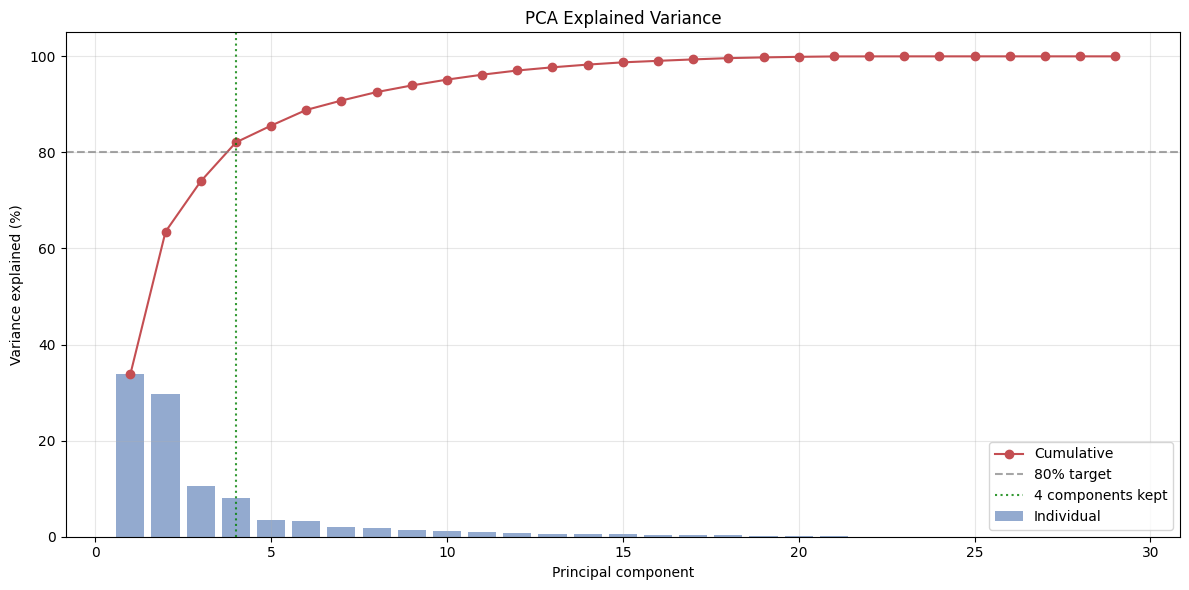

In [4]:
sm = train_signal_model(df, model=MODEL, threshold=THRESHOLD)
kept = sm.pca.n_components
print(f"Kept {kept} components — "
      f"{sm.pca.explained_variance_ratio[:kept].sum()*100:.1f}% variance")
fig = plot_pca_variance(sm.pca); plt.show()

## 4 · ML Model & Signal

Target = **next-day return > 0**. Signal = **Long** if P(up) > 0.60, else **Flat**.

Model: gradient_boosting
Test window: 2025-01-24 -> 2026-07-07 (363 days)
LONG on 115/363 test days


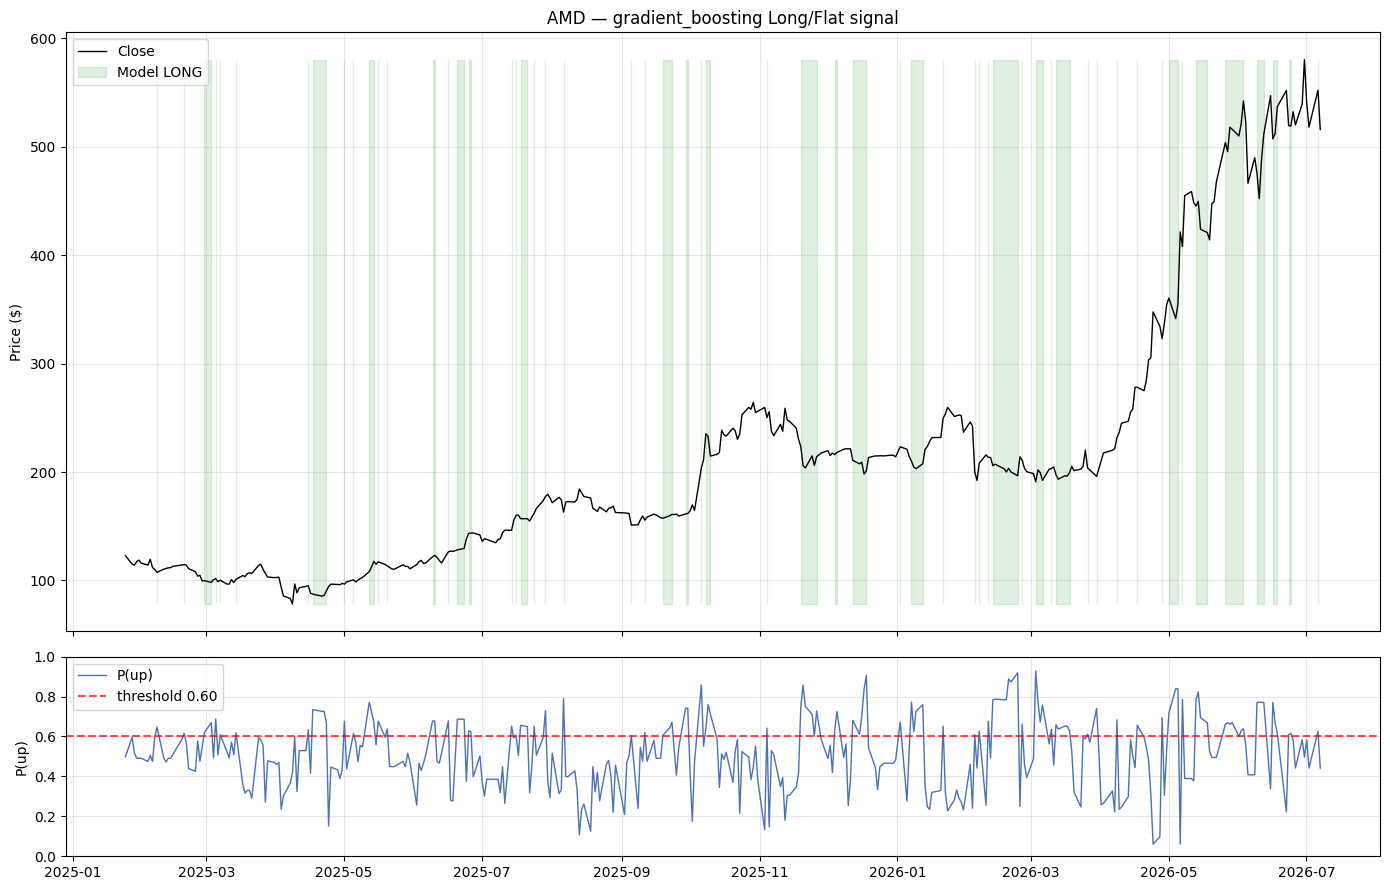

In [5]:
print(f"Model: {sm.name}")
print(f"Test window: {sm.test_index[0].date()} -> {sm.test_index[-1].date()} "
      f"({len(sm.test_index)} days)")
print(f"LONG on {int(sm.signal.sum())}/{len(sm.signal)} test days")
df_test = sm.test_frame()
fig = plot_signal(df_test, sm.proba, sm.signal, sm.threshold,
                  f"{TICKER} — {MODEL} Long/Flat signal"); plt.show()

## 5 · Backtest — ML Signal vs Buy & Hold

$100k, long-only, no leverage, no shorting. Positions act on the next bar.

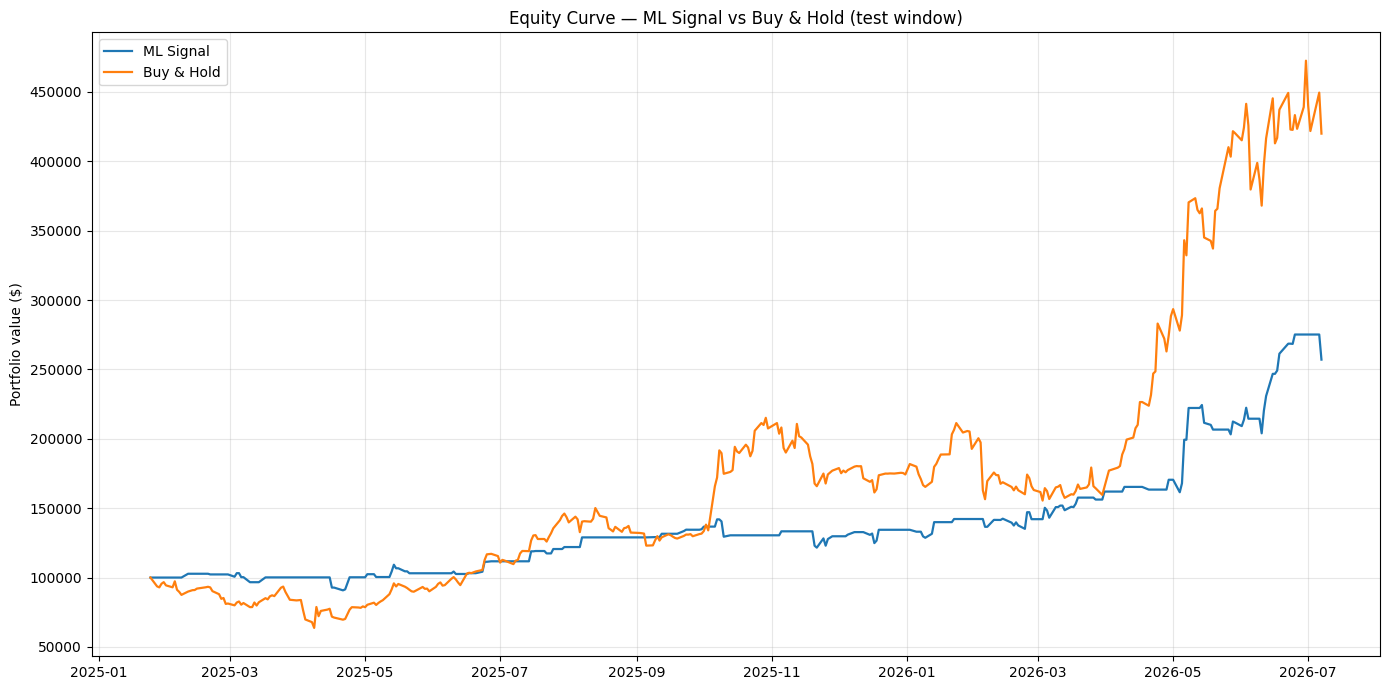

In [6]:
ml = run_backtest(df_test, sm.signal, initial_capital=100_000)
bh = run_backtest(df_test, pd.Series(1, index=df_test.index), initial_capital=100_000)
results = {"ML Signal": ml, "Buy & Hold": bh}
fig = plot_equity_curves(results); plt.show()

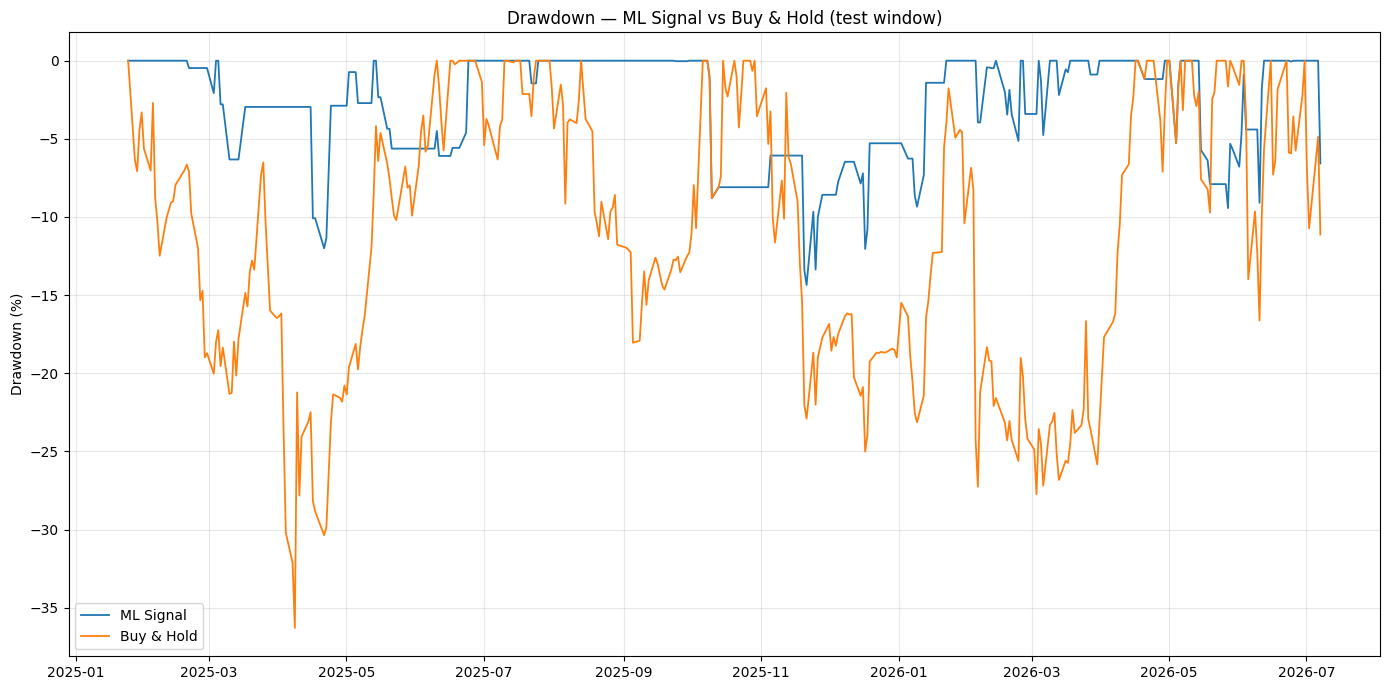

In [7]:
fig = plot_drawdowns(results); plt.show()

## 6 · Performance Metrics

Total Return, CAGR, Volatility, Sharpe, Sortino, Max Drawdown, Win Rate.

In [8]:
metrics_table(results)

,Total Return,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Win Rate,Trades
ML Signal,157.07%,92.61%,35.35%,2.03,2.17,-14.35%,63.16%,57
Buy & Hold,319.95%,170.79%,66.63%,1.82,3.09,-36.29%,100.00%,1


## 7 · Paper Trading Demo

Run from a terminal (submits a **paper** order to Alpaca):

```bash
python paper_trade.py --ticker AAPL --qty 5           # follow the model
python paper_trade.py --ticker AAPL --qty 5 --force buy  # guarantee a demo trade
```

The script fetches the latest data, rebuilds features, applies PCA, generates
the ML signal, and submits a **BUY** (Long) or **SELL** (Flat) order to the
Alpaca paper endpoint. See the README for the dashboard screenshot + logs.

> ⚠️ **PAPER TRADING ONLY — no real money is used.**